# BLC-15314, ID10-EH1, 19.04.2024, E0=22.5 keV, beam HxV= 26x16 microns

In [1]:
from XRR import XRR
from XRR import rebin
import numpy as np
import matplotlib.pyplot as plt

In [112]:
FileDir = 'D:/Synchrotron data/ID10B_XRR_GISAXS_Oct23/SDS_50mM_4000/SDS_50mM_4000_0001'
FileName = '/SDS_50mM_4000_0001.h5'
ScanN_list = [7,8,9,10,11]
file = FileDir+FileName  

Start loading data.
Loaded scan #7
Loading scan  8
Loaded scan #8
Loading scan  9
Loaded scan #9
Loading scan  10
Loaded scan #10
Loading scan  11
Loaded scan #11
Loading completed. Reading time 0.325 sec
Starting 2D data processing.
Number of points in the scan    291 

Processing completed. Processing time 0.037 sec 




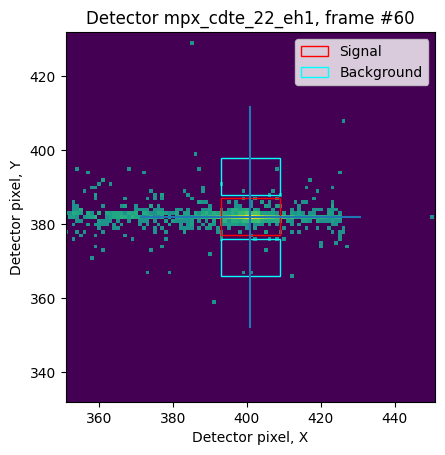

In [125]:
refl = XRR(file, ScanN_list, PX0=401, PY0 = 382, dPX=8, dPY=5, I0=8.10e12,transmission_name='autof_eh1_transm', att_name='autof_eh1_curratt', energy_name='eccmono', alpha_i_name='chi')
refl.show_detector_image(60)
#plt.xlim(100, 440)
#plt.ylim(0, 512)

Start loading data.
Loaded scan #7
Loading scan  8
Loaded scan #8
Loading scan  9
Loaded scan #9
Loading scan  10
Loaded scan #10
Loading scan  11
Loaded scan #11
Loading completed. Reading time 0.347 sec
Starting 2D data processing.
Number of points in the scan    291 

Processing completed. Processing time 0.047 sec 


Reloaded and reprocessed data. 


Footprint correction completed with beam size = 13 microns and sample size = 2 cm



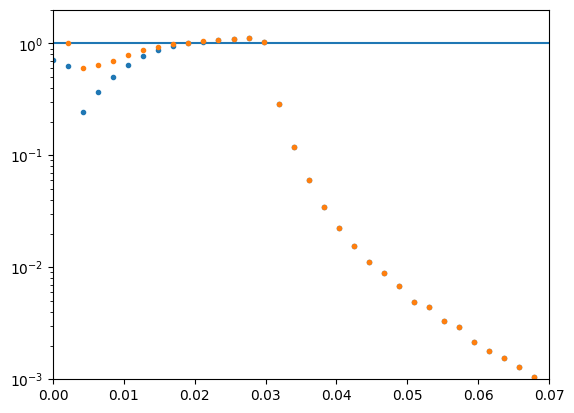

In [126]:
refl.I0 = 4.05e12
refl.reprocess()
plt.errorbar(*refl.get_reflectivity()[:,0:], capsize=1, fmt='.')
#refl.correct_doubles()
refl.footprint_correction(2, 13, correct_dir_beam=True)

plt.errorbar(*refl.get_reflectivity()[:,0:], capsize=1, fmt='.')
plt.semilogy()
plt.xlim(0, 0.07)
plt.ylim(0.001, 2)
plt.hlines(1,0, 0.2)


Starting q-space mapping.
2D map calculated. Processing time 2.949 sec
Saving Q-space map.


(0.0, 0.5)

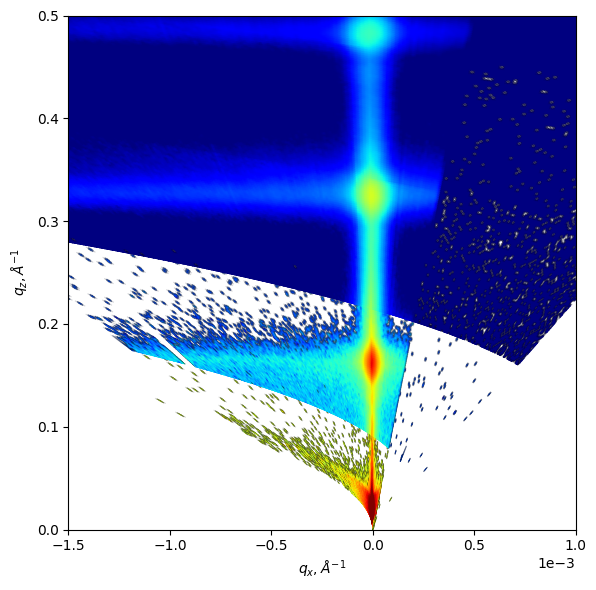

In [127]:
refl.produce_Qmap(SDD=700)
fig, ax = refl.plot_Qmap(save=True)

#ax.hlines(0.15, -1, 1)
#ax.hlines(0.165*2, -1, 1)
ax.set_xlim(-0.0015, 0.001)
ax.set_ylim(0, 0.5)


Saving reflectivity plot.
Reflectivity saved to dir: C:\Users\bersenev\Desktop\Data analysis\XRR 
 filename: SDS_50mM_4000_xrr_scan_[ 7  8  9 10 11].dat


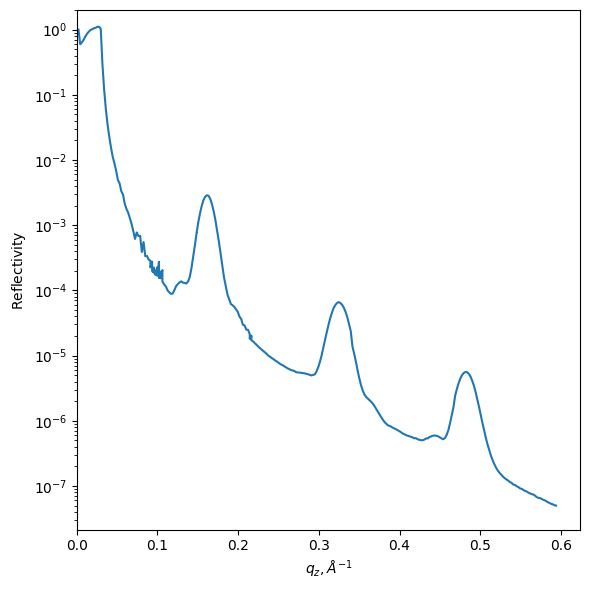

In [128]:
refl.plot_reflectivity(save=True)
refl.save_reflectivity()

In [103]:
#plt.imshow(np.log10(np.array(refl.Smap2D)))
#ax = plt.gca()
#ax.set_yticks(range(len(refl.qz))[::100], np.round(refl.qz[::100], 3))

(1e-11, 1e-05)

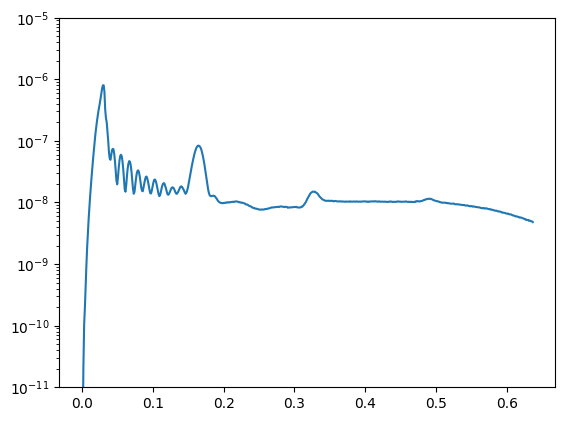

In [104]:
plt.semilogy(refl.qz, refl.reflectivity*refl.qz**4)
plt.ylim(1e-11, 1e-5)
#plt.semilogy(refl.qz, refl.bckg)